# Analysis of the ParlaMint-SI corpus: sentence-level annotations


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


df = pd.read_csv('../../Datasets/ParlaMint-SI.tsv', delimiter='\t', encoding='utf-8')
df.head()

,ID,sent_id,text,text_en,s_annotations,s_labels,s_sentiment,u_annotations,u_label,u_sentiment,...,Speaker_MP,Speaker_minister,Speaker_party,Speaker_party_name,Party_status,Party_orientation,Speaker_ID,Speaker_name,Speaker_gender,Speaker_birth
0,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Spoštovane kolegice poslanke in kolegi poslanc...,"Dear fellow Members and fellow Members, ladies...",4.052144,Mixed Positive,Positive,2.42,Neutral Negative,Neutral,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Začenjam z nadaljevanjem 99. izredne seje Drža...,I'm starting with the 99th Extraordinary Meeti...,3.223034,Neutral Positive,Neutral,2.42,Neutral Negative,Neutral,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953
2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,"Obveščen sem, da se današnje seje ne morejo ud...",I am informed that today's meeting cannot be a...,1.778516,Neutral Negative,Neutral,2.42,Neutral Negative,Neutral,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Vse prisotne lepo pozdravljam!,I say hello to everyone who's here!,4.814360,Positive,Positive,2.42,Neutral Negative,Neutral,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953
4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Prehajamo na 10.,We're moving on to 10.,3.219104,Neutral Positive,Neutral,2.42,Neutral Negative,Neutral,...,MP,notMinister,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953


In [2]:
check_min = df['s_annotations'].min()
check_max = df['s_annotations'].max()
print("Lowest s-annotation value: ", check_min)
print("Highest s-annotation value: ", check_max)

Lowest s-annotation value:  -0.167532429099082
Highest s-annotation value:  5.716129779815674


## Additional preprocessing for the sentence-level analysis

Dropping all utterance-related columns, and adding both 6-class and 3-class labels (columns ```labels``` (6-class label) and ```sentiment``` (3-class label)) for sentence-level annotations


In [3]:
#Drop all utterance-related fields and add 6-class labels for sentence-level annotations
label_mapping = {
    0: 'Negative',
    1: 'Mixed Negative',
    2: 'Neutral Negative',
    3: 'Neutral Positive',
    4: 'Mixed Positive',
    5: 'Positive'
}
df = df.drop(columns=['ID', 'u_annotations', 'u_label', 'u_sentiment'])
df = df.rename(columns={'sent_id':'ID'})

annotations = np.clip(np.round(df['s_annotations']), 0, 5).astype(int)
df['annotations_clip'] = annotations
df['labels'] = df['annotations_clip'].map(label_mapping)


In [4]:
#Adding 3-class labels for sentence-level annotations
mapping = {
    0: 'Negative',
    1: 'Neutral',   
    2: 'Positive',
}

sentiment = np.floor_divide(df['annotations_clip'], 2)
df['sentiment_no'] = sentiment
df['sentiment'] = df['sentiment_no'].map(mapping)
df = df.drop(columns=['annotations_clip', 'sentiment_no'])

df.head()

,ID,text,text_en,s_annotations,s_labels,s_sentiment,h_annotations,h_labels,h_sentiment,Text_ID,...,Speaker_party,Speaker_party_name,Party_status,Party_orientation,Speaker_ID,Speaker_name,Speaker_gender,Speaker_birth,labels,sentiment
0,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Spoštovane kolegice poslanke in kolegi poslanc...,"Dear fellow Members and fellow Members, ladies...",4.052144,Mixed Positive,Positive,2.401479,Neutral Negative,Neutral,ParlaMint-SI-en_2022-04-06-SDZ8-Izredna-99,...,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953,Mixed Positive,Positive
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Začenjam z nadaljevanjem 99. izredne seje Drža...,I'm starting with the 99th Extraordinary Meeti...,3.223034,Neutral Positive,Neutral,2.401479,Neutral Negative,Neutral,ParlaMint-SI-en_2022-04-06-SDZ8-Izredna-99,...,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953,Neutral Positive,Neutral
2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,"Obveščen sem, da se današnje seje ne morejo ud...",I am informed that today's meeting cannot be a...,1.778516,Neutral Negative,Neutral,2.401479,Neutral Negative,Neutral,ParlaMint-SI-en_2022-04-06-SDZ8-Izredna-99,...,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953,Neutral Negative,Neutral
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Vse prisotne lepo pozdravljam!,I say hello to everyone who's here!,4.814360,Positive,Positive,2.401479,Neutral Negative,Neutral,ParlaMint-SI-en_2022-04-06-SDZ8-Izredna-99,...,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953,Positive,Positive
4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,Prehajamo na 10.,We're moving on to 10.,3.219104,Neutral Positive,Neutral,2.401479,Neutral Negative,Neutral,ParlaMint-SI-en_2022-04-06-SDZ8-Izredna-99,...,DeSUS,Demokratična stranka upokojencev Slovenije,Coalition,Centre to centre-left,SimonovičBranko,"Simonovič, Branko",M,1953,Neutral Positive,Neutral


Fixing Term 5-6 and Term 7-8 overlaps identified in the original data (debate transcriptions), corrected in ParlaMint-SI 5.0:

- Term 5: 15.10.2008 - 21.12.2011
- Term 6: 21.12.2011 - 01.08.2014
- Term 7: 01.08.2014 - 22.06.2018
- Term 8: 22.06.2018 - 13.05.2022


In [5]:
# Renaming slv metadata to eng (X. mandat -> Term X)
df['Term'] = df['Term'].replace({
    '3. mandat': 'Term 3',
    '4. mandat': 'Term 4',
    '5. mandat': 'Term 5',
    '6. mandat': 'Term 6',
    '7. mandat': 'Term 7',
    '8. mandat': 'Term 8'
})
df['Year'] = df['Date'].str.split('-').str[0]

term6 = df[df['Year'] == '2012']
update_term6 = term6.index
df.loc[update_term6, 'Term'] = 'Term 6'

term5_check = df[df['Term'] == 'Term 5']
print("Earliest Term5 speech: ", term5_check['Date'].min())
print("Last Term5 speech: ", term5_check['Date'].max())

term6_check = df[df['Term'] == 'Term 6']
print("Earliest Term6 speech: ", term6_check['Date'].min())
print("Last Term6 speech: ", term6_check['Date'].max())

term7 = df[(df['Date'] == '2018-10-11') & (df['ID'].str.contains('ParlaMint-SI_2018-10-11-SDZ7-Izredna-49.ana'))]
update_term7 = term7.index
df.loc[update_term7, 'Term'] = 'Term 8'

term7_check = df[df['Term'] == 'Term 7']
print("Earliest Term7 speech: ", term7_check['Date'].min())
print("Last Term7 speech: ", term7_check['Date'].max())

term8_check = df[df['Term'] == 'Term 8']
print("Earliest Term8 speech: ", term8_check['Date'].min())
print("Last Term8 speech: ", term8_check['Date'].max())


Earliest Term5 speech:  2008-10-15
Last Term5 speech:  2011-12-08
Earliest Term6 speech:  2011-12-21
Last Term6 speech:  2014-07-04
Earliest Term7 speech:  2014-08-01
Last Term7 speech:  2018-05-24
Earliest Term8 speech:  2018-06-22
Last Term8 speech:  2022-04-06


## Descriptive statistics

Checking (sentiment) distributions within the new ParlaMint-SI corpus and the characteristics of the political parties within.


In [6]:
check_labels = df['labels'].value_counts()
check_labels

labels
Neutral Positive    1432364
Mixed Positive       674991
Negative             548659
Neutral Negative     547982
Mixed Negative       521098
Positive             151089
Name: count, dtype: int64

In [7]:
check_sentiment = df['sentiment'].value_counts()
check_sentiment

sentiment
Neutral     1980346
Negative    1069757
Positive     826080
Name: count, dtype: int64

## Removing procedural sentences
Checking the percentage of procedural sentences in the corpus, removing them and checking ```labels``` and ```sentiment```distributions again.

In [8]:
#Remove procedural sent_annotations from main DataFrame
df = df[df['Speaker_role'] == 'Regular']

df_labels = df['labels'].value_counts()
df_sentiment = df['sentiment'].value_counts()

percent_lables = (df_labels / len(df)) * 100
percent_sent = (df_sentiment / len(df)) * 100

print("Total no. of non-procedural sentences: ", len(df))
print("Earliest sentence: ", df['Date'].min())
print("Last sentence: ", df['Date'].max())
print("Distribution of the labels: ", percent_lables)
print("Distribution of the sentiment: ", percent_sent)


Total no. of non-procedural sentences:  3167031
Earliest sentence:  2000-10-27
Last sentence:  2022-04-06
Distribution of the labels:  labels
Neutral Positive    31.553780
Negative            17.175108
Mixed Negative      16.107389
Neutral Negative    15.954659
Mixed Positive      15.377589
Positive             3.831475
Name: count, dtype: float64
Distribution of the sentiment:  sentiment
Neutral     47.508439
Negative    33.282497
Positive    19.209064
Name: count, dtype: float64


In [9]:
#Checking percentage of procedural sentences

df_procedural = df[df['Speaker_role'] != 'Regular']
percent_procedural = (len(df_procedural) / len(df)) * 100

print("Total no. of sentences: ", len(df))
print("Total no. of procedural sentences: ", len(df_procedural), "%: ", percent_procedural)

Total no. of sentences:  3167031
Total no. of procedural sentences:  0 %:  0.0


## Sentiment trends

In [10]:
parties = df['Speaker_party'].value_counts()
orientations = df['Party_orientation'].value_counts()
status = df['Party_status'].value_counts()

percent_parties = (parties / len(df)) * 100
percent_orientations = (orientations / len(df)) * 100
percent_staus = (status / len(df)) * 100

print("% of sentences per political party:", percent_parties)
print("% of sentences for coalition/opposition: ", percent_staus)
print("% of sentences per political orientation:", percent_orientations)

% of sentences per political party: Speaker_party
SDS          25.913450
-            11.275166
SD           10.543219
NSi           8.799124
LDS           7.217801
SMC           4.857925
SNS           4.776177
SLS           4.232292
DeSUS         4.170783
Levica        3.279475
LMŠ           2.449202
ZLSD          1.863859
PS            1.819749
Zares         1.793099
ZL            1.752777
SAB           1.524425
NP            1.197462
DL            0.746188
NeP           0.519603
SLS+SKD       0.344455
SMS           0.330025
Lipa          0.238425
ZaAB          0.223395
Konkretno     0.076475
DLGV          0.055446
Name: count, dtype: float64
% of sentences for coalition/opposition:  Party_status
Opposition    47.575979
Coalition     36.196520
-             16.227501
Name: count, dtype: float64
% of sentences per political orientation: Party_orientation
Right                     25.968896
Centre to centre-left     20.515461
Centre-left               16.278022
Centre-right            

In [11]:
status = df.groupby(['Speaker_party','Party_status']).size().unstack(fill_value=0)
status.columns = ['Total Sentences (Unknown)', 'Total Sentences (Coalition)', 'Total Sentences (Opposition)']

avg_sentiment = df.groupby(['Speaker_party', 'Party_status'])['s_annotations'].mean().unstack(fill_value=0)
avg_sentiment.columns = ['Avg. Sentiment (Unknown)', 'Avg. Sentiment (Coalition)', 'Avg. Sentiment (Opposition)']

sentiment_counts = df.groupby(['Speaker_party', df['sentiment']]).size().unstack(fill_value=0)
sentiment_percentages = sentiment_counts.div(sentiment_counts.sum(axis=1), axis=0) * 100

party_metadata = df[['Speaker_party', 'Party_orientation']].drop_duplicates().set_index('Speaker_party')

overview = (
    status
    .merge(avg_sentiment, on='Speaker_party', how='left')
    .merge(sentiment_percentages, on='Speaker_party', how='left')
    .reset_index()
)

overview = overview.merge(party_metadata, on='Speaker_party', how='left')

overview.rename(columns={
    'Positive': '% Positive',
    'Neutral': '% Neutral',
    'Negative': '% Negative'
}, inplace=True)

overview['Total Sentences'] = overview['Total Sentences (Unknown)'] + overview['Total Sentences (Coalition)'] + overview['Total Sentences (Opposition)']
total_sent = overview['Total Sentences'].sum()
overview['Sent %'] = (overview['Total Sentences'] / total_sent) * 100
overview = overview[['Speaker_party', 'Party_orientation', 'Total Sentences', 'Sent %', 'Total Sentences (Coalition)', 'Total Sentences (Opposition)','Total Sentences (Unknown)',
               'Avg. Sentiment (Coalition)', 'Avg. Sentiment (Opposition)','Avg. Sentiment (Unknown)', '% Positive', '% Neutral', '% Negative']]

overview['Sent %'] = overview['Sent %'].apply(lambda x: f'{x:.2f}')
overview['Avg. Sentiment (Coalition)'] = overview['Avg. Sentiment (Coalition)'].apply(lambda x: f'{x:.2f}')
overview['Avg. Sentiment (Opposition)'] = overview['Avg. Sentiment (Opposition)'].apply(lambda x: f'{x:.2f}')
overview['Avg. Sentiment (Unknown)'] = overview['Avg. Sentiment (Unknown)'].apply(lambda x: f'{x:.2f}')
overview['% Positive'] = overview['% Positive'].apply(lambda x: f'{x:.2f}')
overview['% Neutral'] = overview['% Neutral'].apply(lambda x: f'{x:.2f}')
overview['% Negative'] = overview['% Negative'].apply(lambda x: f'{x:.2f}')



overview
#print(overview.to_latex(index=False))

,Speaker_party,Party_orientation,Total Sentences,Sent %,Total Sentences (Coalition),Total Sentences (Opposition),Total Sentences (Unknown),Avg. Sentiment (Coalition),Avg. Sentiment (Opposition),Avg. Sentiment (Unknown),% Positive,% Neutral,% Negative
0,-,-,357088,11.28,0,0,357088,0.00,0.00,2.70,21.31,63.26,15.43
1,DL,Centre to centre-right,23632,0.75,22192,1302,138,2.44,2.52,2.10,23.44,48.95,27.62
2,DLGV,Right,1756,0.06,1076,0,680,2.65,0.00,2.91,33.71,43.00,23.29
3,DeSUS,Centre to centre-left,132090,4.17,128935,3120,35,2.58,2.76,3.41,27.16,48.68,24.17
4,Konkretno,Centre,2422,0.08,2422,0,0,2.80,0.00,0.00,31.34,50.33,18.33
5,LDS,Centre to centre-left,228590,7.22,119975,108338,277,2.44,2.03,3.29,19.63,47.66,32.71
6,LMŠ,Centre to centre-left,77567,2.45,15169,61786,612,2.47,1.79,2.73,14.68,42.59,42.73
7,Levica,Left,103862,3.28,0,103862,0,0.00,1.73,0.00,12.55,37.85,49.60
8,Lipa,-,7551,0.24,0,0,7551,0.00,0.00,1.91,14.75,41.08,44.17
9,NP,-,37924,1.20,0,0,37924,0.00,0.00,2.12,17.73,44.46,37.81


#### Party activity

Checking party activity and other trends that allow for a good term characteristics overview.
For these analyses, the question of how to treat "non-parties" (NeP and NP) and anomalys (such as Lipa, Konkretno) are directly tied to visualisation and data granularity. 
- NeP = parliamentary group of independent MPs, which could be considered for the analysis, however, since there is no destinction between different NePs in different mandates, this should be ruled out
- NP = individual independent MPs, not connected into a parliamentary group. In addition to them not being a formal parliamentary entity but individual speakers, they have similar problem as NeP, ruled out
- Lipa and Konkretno = both are non-parliamentary parties. Specfically, both parties were consistuted within Parliament after being elected as a different parliamentary party. Therefore, the party was never directly voted into the Parliament, however, individual MPs, that were elected into the Parliament are still MPs, but within a new party. Since they did produce some speeches (and sentences) within their (very short) terms, they should be kept in the analysis.
- '-' = individual speakers without formal political party affiliation. As we are interested in party activity, they will not be a part of the analysis.
- Some parties have been renamed during the course of their existence within the Parliament, and are in essence a direct continuation of one another (ParlaMint-SI listOrg ```<listEvent>```):
    - SDS.1 (Socialdemokratska stranka Slovenije) -> SDS.2 (Slovenska demokratska stranka)
    - ZL (Levica.1) -> Levica (Levica.2)
    - ZaAB -> ZaSLD -> SAB
    - ZLSD -> SD
    - SLS+SKD -> SLS
    - DLGV -> DL
    - SMC.1 (Stranka Mira Cerarja) -> SMC.2 (Stranka modernega centra) + GAS -> Konkretno (SMC/GAS/Konkretno)

Two versions of the Gantt plot: 
- Visualising party activity with parties as they are.
- Visualising party activity with grouped parties
- Ideally, both plots can be used (with different colour palette) within the Chapter

In [12]:
# Groups of political parties, as per <listEvent> 
groups = {
    "ZL": "ZL/Levica",
    "Levica": "ZL/Levica",
    "ZaAB":"ZaAB/ZaSLD/SAB",
    "ZaSLD":"ZaAB/ZaSLD/SAB",
    "SAB" :"ZaAB/ZaSLD/SAB",
    "ZLSD":"ZLSD/SD",
    "SD":"ZLSD/SD",
    "SLS+SKD":"SLS+SKD/SLS",
    "SLS":"SLS+SKD/SLS", 
    "DLGV":"DLGV/DL", 
    "DL":"DLGV/DL",
    "SMC":"SMC/GAS/Konkretno",
    "Konkretno": "SMC/GAS/Konkretno"

}

In [13]:
activity = df.groupby(['Term', 'Speaker_party']).agg(
    Start_date=('Date', 'min'),
    End_date=('Date', 'max'),
    Sent_count=('Date', 'size')
).reset_index()
activity = activity[~activity['Speaker_party'].isin(["-", "NeP", "NP"])]

activity["Grouped_parties"] = activity['Speaker_party'].replace(groups).fillna(activity['Speaker_party'])
activity.head()

,Term,Speaker_party,Start_date,End_date,Sent_count,Grouped_parties
1,Term 3,DeSUS,2000-10-27,2004-10-07,9997,DeSUS
2,Term 3,LDS,2000-10-27,2004-10-07,87341,LDS
3,Term 3,NSi,2000-10-27,2004-10-07,69860,NSi
5,Term 3,SDS,2000-11-10,2004-10-07,93432,SDS
6,Term 3,SLS,2002-03-19,2004-10-07,29642,SLS+SKD/SLS


In [14]:
import plotly.express as px
from PIL import Image

## Plot 1: ALL parties as are
fig = px.timeline(
    activity,
    x_start="Start_date",
    x_end="End_date",
    y="Speaker_party",
    color="Sent_count",
    title="Party Activity Across Terms (Gantt Chart)",
    labels={"Sent_count": "Party Activity"},
)
fig.update_layout(
    height=600  # Set the height to your desired value
)

#fig.write_html("./Figures/Sentiment_Analysis/Parties/Party_activity_Gantt.html")
fig.write_image("./Figures/Sentiment_Analysis/Sentences/Party_activity.png")

fig.show()

In [15]:
fig = px.timeline(
    activity,
    x_start="Start_date",
    x_end="End_date",
    y="Grouped_parties",
    color="Sent_count",
    title="Party Activity Across Terms (Gantt Chart)",
    labels={"Sent_count": "Party Activity"},
    color_continuous_scale="viridis"

)
fig.update_layout(
    height=600,
    xaxis_title="Years",
    yaxis_title="Political Parties",
    legend_title="Grouped Parties",
    barmode = "stack"
)
fig.write_image("./Figures/Sentiment_Analysis/Sentences/Party_activity_grouped.png")

fig.show()

## Sentiment (Removed procedural speech)

### General corpus distributions

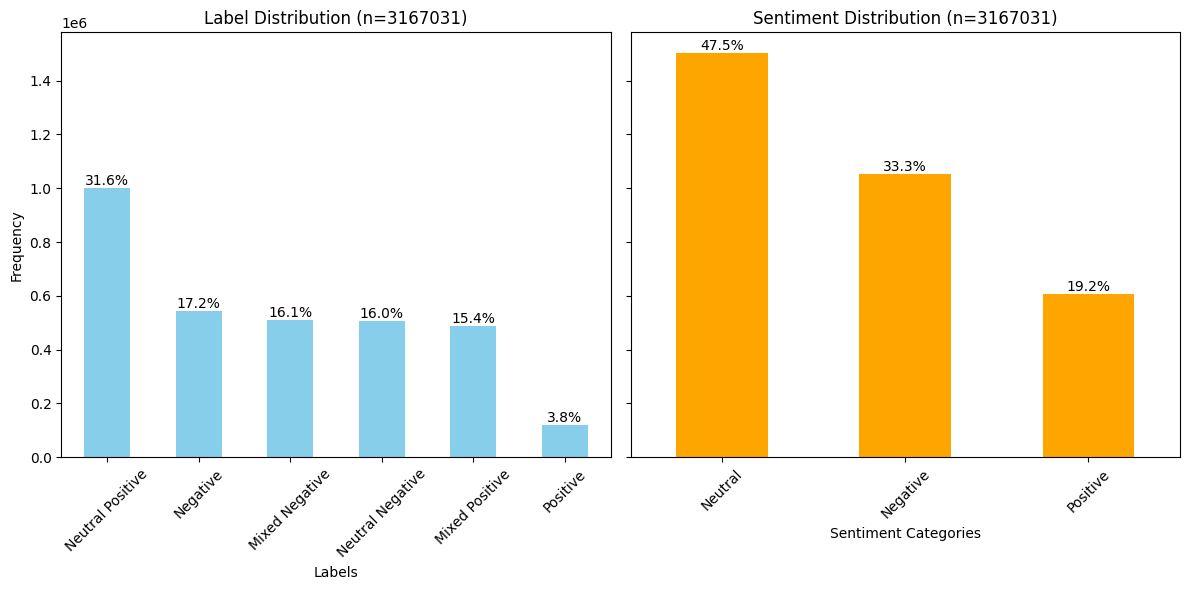

In [16]:
def add_percentage(ax, counts):
    total = counts.sum()
    for p in ax.patches:
        percentage = f"{(p.get_height() / total) * 100:.1f}%"
        ax.annotate(percentage,  (p.get_x() + p.get_width() / 2, p.get_height()), 
                    ha='center', va='bottom', fontsize=10, color='black')

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
df_labels.plot(kind='bar', ax=axes[0], color = 'skyblue')
axes[0].set_title('Label Distribution (n=3167031)')
axes[0].set_xlabel('Labels')
axes[0].set_ylabel('Frequency')
axes[0].tick_params(axis='x', rotation=45)
add_percentage(axes[0], df_labels)

df_sentiment.plot(kind='bar', ax=axes[1], color='orange')
axes[1].set_title('Sentiment Distribution (n=3167031)')
axes[1].set_xlabel('Sentiment Categories')
axes[1].tick_params(axis='x', rotation=45)
add_percentage(axes[1], df_sentiment)

plt.tight_layout()
#plt.savefig('./Figures/Sentiment_Analysis/Sentences/Sentiment_distribution.png', dpi=300)
plt.show()

### Sentiment per party status

In [17]:
pivot_status = pd.crosstab(df['Party_status'], df['sentiment']).reindex(['Opposition', 'Coalition', '-'])
#pivot_status = pivot_status.loc[pivot_status.index != '-']

pivot_status['Total'] = pivot_status.sum(axis=1)
pivot_status['% Negative'] = (pivot_status['Negative'] / pivot_status['Total'])*100
pivot_status['% Neutral'] = (pivot_status['Neutral'] / pivot_status['Total'])*100
pivot_status['% Positive'] = (pivot_status['Positive'] / pivot_status['Total'])*100

pivot_status['% Negative'] = pivot_status['% Negative'].round(2)
pivot_status['% Neutral'] = pivot_status['% Neutral'].round(2)
pivot_status['% Positive'] = pivot_status['% Positive'].round(2)

pivot_status

sentiment,Negative,Neutral,Positive,Total,% Negative,% Neutral,% Positive
Party_status,,,,,,,
Opposition,636392,639847,230507,1506746,42.24,42.47,15.30
Coalition,302891,569965,273499,1146355,26.42,49.72,23.86
-,114784,294795,104351,513930,22.33,57.36,20.30


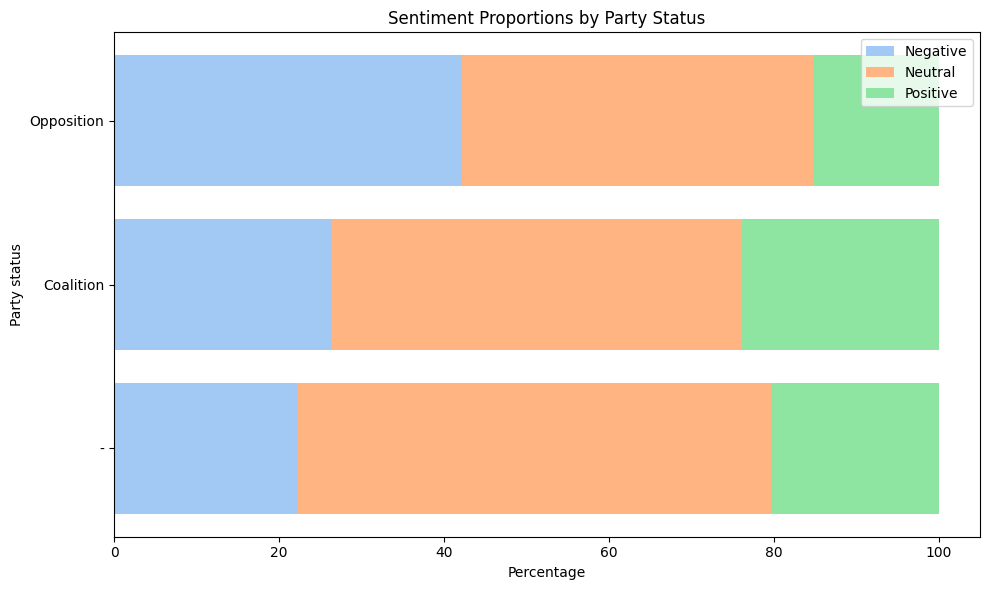

In [18]:
palette2 = sns.color_palette('pastel', 3)
pivot_status = pivot_status.sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(pivot_status.index, pivot_status['% Negative'], label='Negative', color=palette2[0])
ax.barh(pivot_status.index, pivot_status['% Neutral'], left=pivot_status['% Negative'], label='Neutral', color=palette2[1])
ax.barh(pivot_status.index, pivot_status['% Positive'], left=pivot_status['% Negative'] + pivot_status['% Neutral'], label='Positive', color=palette2[2])

ax.set_ylabel("Party status")
ax.set_xlabel("Percentage")
ax.set_title("Sentiment Proportions by Party Status")
ax.legend()

plt.tight_layout()
#plt.savefig('./Figures/Sentiment_Analysis/Sentences/Party_status.png', dpi=300)
plt.show()

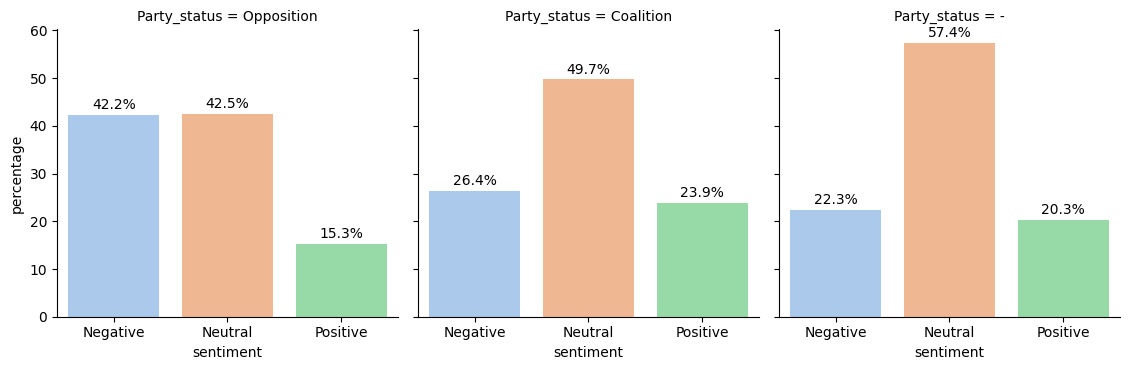

In [19]:
df_melted = pivot_status.reset_index().melt(id_vars="Party_status", 
                                             value_vars=["% Negative", "% Neutral", "% Positive"], 
                                             var_name="sentiment", 
                                             value_name="percentage")

sentiment_mapping = {
    "% Negative": "Negative",
    "% Neutral": "Neutral",
    "% Positive": "Positive"
}
df_melted["sentiment"] = df_melted["sentiment"].map(sentiment_mapping)

g = sns.FacetGrid(df_melted, col="Party_status", margin_titles=True, col_order=['Opposition', 'Coalition', '-'], height=3.8, sharey=True)
g.map_dataframe(sns.barplot, x="sentiment", y="percentage", order=["Negative", "Neutral", "Positive"], hue="sentiment", palette="pastel", dodge=False)

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", label_type="edge", fontsize=10, padding=2)

#plt.savefig('./Figures/Sentiment_Analysis/Sentiment_per_Party_status.png', dpi=300)
plt.show()

### Sentiment per Political Orientations

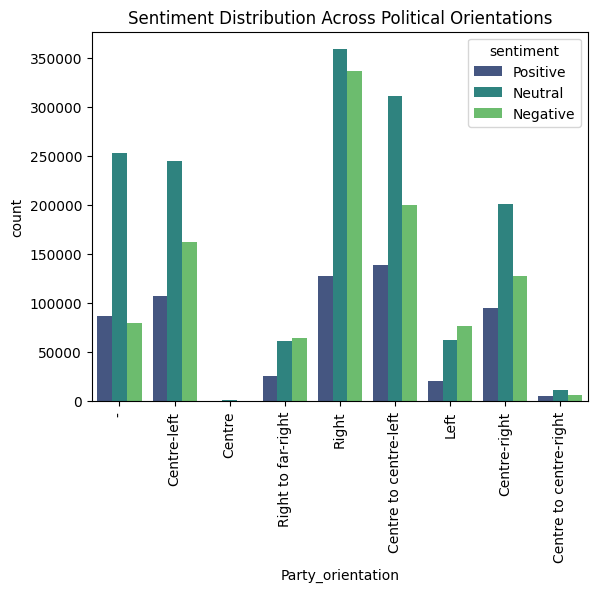

In [20]:
sns.countplot(data=df, x='Party_orientation', hue='sentiment', order=df['Party_orientation'].unique(), palette='viridis')
plt.xticks(rotation=90)
plt.title('Sentiment Distribution Across Political Orientations')
#plt.savefig('./Figures/Sentiment_Analysis/Sentiment_per_Orientation.png', dpi=300)

plt.show()

In [21]:
pivot_orientation = pd.crosstab(df['Party_orientation'], df['sentiment'])
pivot_orientation = pivot_orientation.loc[pivot_orientation.index != '-']

pivot_orientation['Total'] = pivot_orientation.sum(axis=1)
pivot_orientation['% Negative'] = (pivot_orientation['Negative'] / pivot_orientation['Total'])*100
pivot_orientation['% Neutral'] = (pivot_orientation['Neutral'] / pivot_orientation['Total'])*100
pivot_orientation['% Positive'] = (pivot_orientation['Positive'] / pivot_orientation['Total'])*100

pivot_orientation['% Negative'] = pivot_orientation['% Negative'].round(2)
pivot_orientation['% Neutral'] = pivot_orientation['% Neutral'].round(2)
pivot_orientation['% Positive'] = pivot_orientation['% Positive'].round(2)

pivot_orientation
#print(pivot_orientation.to_latex(multirow=True))

sentiment,Negative,Neutral,Positive,Total,% Negative,% Neutral,% Positive
Party_orientation,,,,,,,
Centre,444,1219,759,2422,18.33,50.33,31.34
Centre to centre-left,199723,311254,138754,649731,30.74,47.91,21.36
Centre to centre-right,6526,11567,5539,23632,27.62,48.95,23.44
Centre-left,162714,245337,107479,515530,31.56,47.59,20.85
Centre-right,127862,200684,95072,423618,30.18,47.37,22.44
Left,76369,62119,20885,159373,47.92,38.98,13.10
Right,336500,358603,127340,822443,40.91,43.60,15.48
Right to far-right,64334,61340,25589,151263,42.53,40.55,16.92


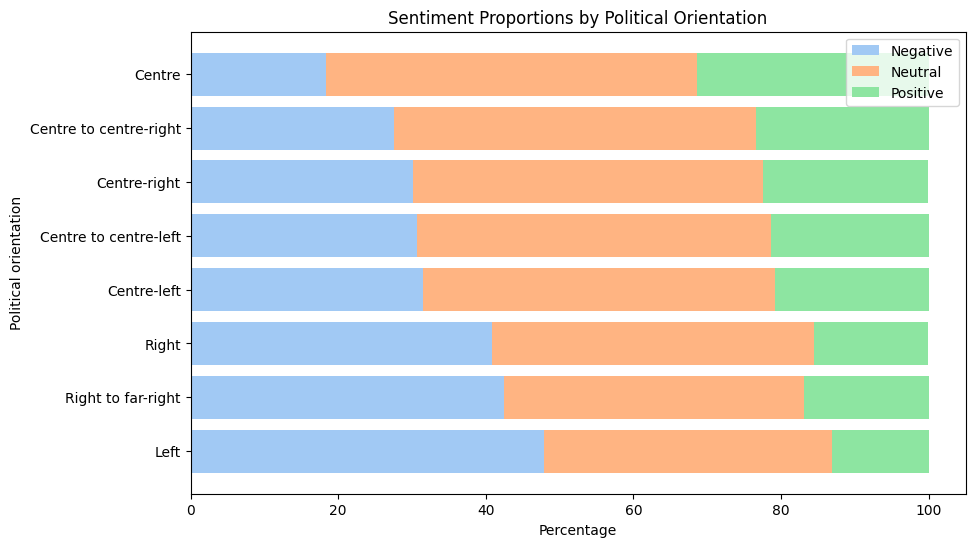

In [22]:
palette2 = sns.color_palette('pastel', 3)
pivot_orientation = pivot_orientation.sort_values(by='% Negative', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(pivot_orientation.index, pivot_orientation['% Negative'], label='Negative', color=palette2[0])
ax.barh(pivot_orientation.index, pivot_orientation['% Neutral'], left=pivot_orientation['% Negative'], label='Neutral', color=palette2[1])
ax.barh(pivot_orientation.index, pivot_orientation['% Positive'], left=pivot_orientation['% Negative'] + pivot_orientation['% Neutral'], label='Positive', color=palette2[2])

ax.set_ylabel("Political orientation")
ax.set_xlabel("Percentage")
ax.set_title("Sentiment Proportions by Political Orientation")
ax.legend()

plt.tight_layout
#plt.savefig('./Figures/Sentiment_Analysis/Sentences/Political_Orientation.png', dpi=300)
plt.show()

### Sentiment per Political parties

In [23]:
pivot_parties = pd.crosstab(df['Speaker_party'], df['sentiment'])
pivot_parties = pivot_parties.loc[pivot_parties.index != '-']

pivot_parties['Total'] = pivot_parties.sum(axis=1)
pivot_parties['% Negative'] = (pivot_parties['Negative'] / pivot_parties['Total']) * 100
pivot_parties['% Neutral'] = (pivot_parties['Neutral'] / pivot_parties['Total']) * 100
pivot_parties['% Positive'] = (pivot_parties['Positive'] / pivot_parties['Total']) * 100


pivot_parties['% Negative'] = pivot_parties['% Negative'].round(2)
pivot_parties['% Neutral'] = pivot_parties['% Neutral'].round(2)
pivot_parties['% Positive'] = pivot_parties['% Positive'].round(2)


pivot_parties
#print(pivot_parties.to_latex(multirow = True))

sentiment,Negative,Neutral,Positive,Total,% Negative,% Neutral,% Positive
Speaker_party,,,,,,,
DL,6526,11567,5539,23632,27.62,48.95,23.44
DLGV,409,755,592,1756,23.29,43.00,33.71
DeSUS,31921,64296,35873,132090,24.17,48.68,27.16
Konkretno,444,1219,759,2422,18.33,50.33,31.34
LDS,74782,108942,44866,228590,32.71,47.66,19.63
LMŠ,33144,33039,11384,77567,42.73,42.59,14.68
Levica,51518,39308,13036,103862,49.60,37.85,12.55
Lipa,3335,3102,1114,7551,44.17,41.08,14.75
NP,14339,16862,6723,37924,37.81,44.46,17.73


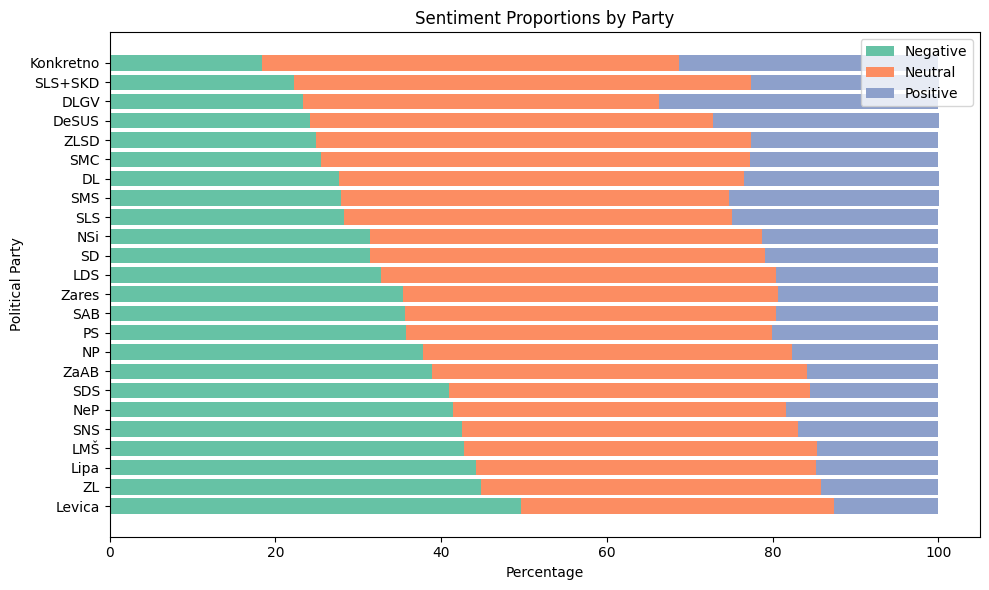

In [24]:
palette = sns.color_palette("Set2", 3)
pivot_parties = pivot_parties.sort_values(by='% Negative', ascending=False)


fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(pivot_parties.index, pivot_parties['% Negative'], label='Negative',  color=palette[0])
ax.barh(pivot_parties.index, pivot_parties['% Neutral'], label='Neutral', left=pivot_parties['% Negative'], color=palette[1])
ax.barh(pivot_parties.index, pivot_parties['% Positive'], left=pivot_parties['% Negative'] + pivot_parties['% Neutral'], label='Positive', color=palette[2])

ax.set_ylabel('Political Party')
ax.set_xlabel('Percentage')
ax.set_title('Sentiment Proportions by Party')
ax.legend()

plt.tight_layout()
#plt.savefig('./Figures/Sentiment_Analysis/Sentences/Parties.png', dpi=300)
plt.show()

### Sentiment per Term

In [25]:
pivot_term = pd.crosstab(df['Term'], df['sentiment'])
pivot_term = pivot_term.loc[pivot_term.index != '-']

pivot_term['Total'] = pivot_term.sum(axis=1)
pivot_term['% Negative'] = (pivot_term['Negative'] / pivot_term['Total'])*100
pivot_term['% Neutral'] = (pivot_term['Neutral'] / pivot_term['Total'])*100
pivot_term['% Positive'] = (pivot_term['Positive'] / pivot_term['Total'])*100

pivot_term['% Negative'] = pivot_term['% Negative'].round(2)
pivot_term['% Neutral'] = pivot_term['% Neutral'].round(2)
pivot_term['% Positive'] = pivot_term['% Positive'].round(2)

pivot_term
#print(pivot_term.to_latex(multirow=True))


sentiment,Negative,Neutral,Positive,Total,% Negative,% Neutral,% Positive
Term,,,,,,,
Term 3,129556,216528,82673,428757,30.22,50.50,19.28
Term 4,177165,271340,121583,570088,31.08,47.60,21.33
Term 5,172103,239932,100802,512837,33.56,46.79,19.66
Term 6,127576,174436,72445,374457,34.07,46.58,19.35
Term 7,226697,317178,116621,660496,34.32,48.02,17.66
Term 8,220970,285193,114233,620396,35.62,45.97,18.41


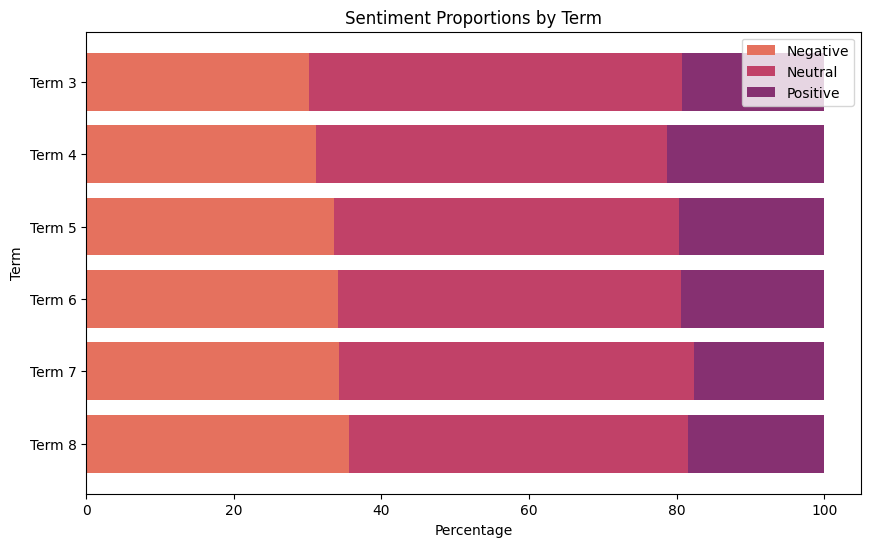

In [26]:
palette3 = sns.color_palette('flare', 3)
pivot_term = pivot_term.sort_values(by='% Negative', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(pivot_term.index, pivot_term['% Negative'], label='Negative', color=palette3[0])
ax.barh(pivot_term.index, pivot_term['% Neutral'], left=pivot_term['% Negative'], label='Neutral', color=palette3[1])
ax.barh(pivot_term.index, pivot_term['% Positive'], left=pivot_term['% Negative'] + pivot_term['% Neutral'], label='Positive', color=palette3[2])

ax.set_ylabel("Term")
ax.set_xlabel("Percentage")
ax.set_title("Sentiment Proportions by Term")
ax.legend()

plt.tight_layout
#plt.savefig('./Figures/Sentiment_Analysis/Sentences/Terms.png', dpi=300)
plt.show()

## Checking sentiment across terms

In [27]:
mandates = df[['ID', 'Term', 'Date', 'Year', 'sent_annotations', 'labels', 'sentiment', 'Speaker_party', 'Party_status', 'Party_orientation']]
mandates

KeyError: "['sent_annotations'] not in index"

In [ ]:
import numpy as np
#Droping the dferances, where the speakers are not affiliated with political parties
mandates.replace('-', np.nan, inplace=True)
print(len(mandates))

terms = mandates.copy()
terms['sent_annotations'] = pd.to_numeric(terms['sent_annotations'])
trends = terms.groupby(['Speaker_party', 'Term']).agg({'sent_annotations':'mean'}).reset_index()
trends['Term'] = pd.Categorical(trends['Term'], ordered=True)

trends


/var/folders/l_/t5l44v1s7d9168_x8bm5ly0h0000gn/T/ipykernel_1838/234848941.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



3167031


,Speaker_party,Term,sent_annotations
0,DL,Term 6,2.440156
1,DLGV,Term 6,2.748858
2,DeSUS,Term 3,2.665923
3,DeSUS,Term 4,2.480170
4,DeSUS,Term 5,2.733823
...,...,...,...
59,ZLSD,Term 4,2.241611
60,ZaAB,Term 6,2.548422
61,ZaAB,Term 7,2.034220
62,Zares,Term 4,1.928406


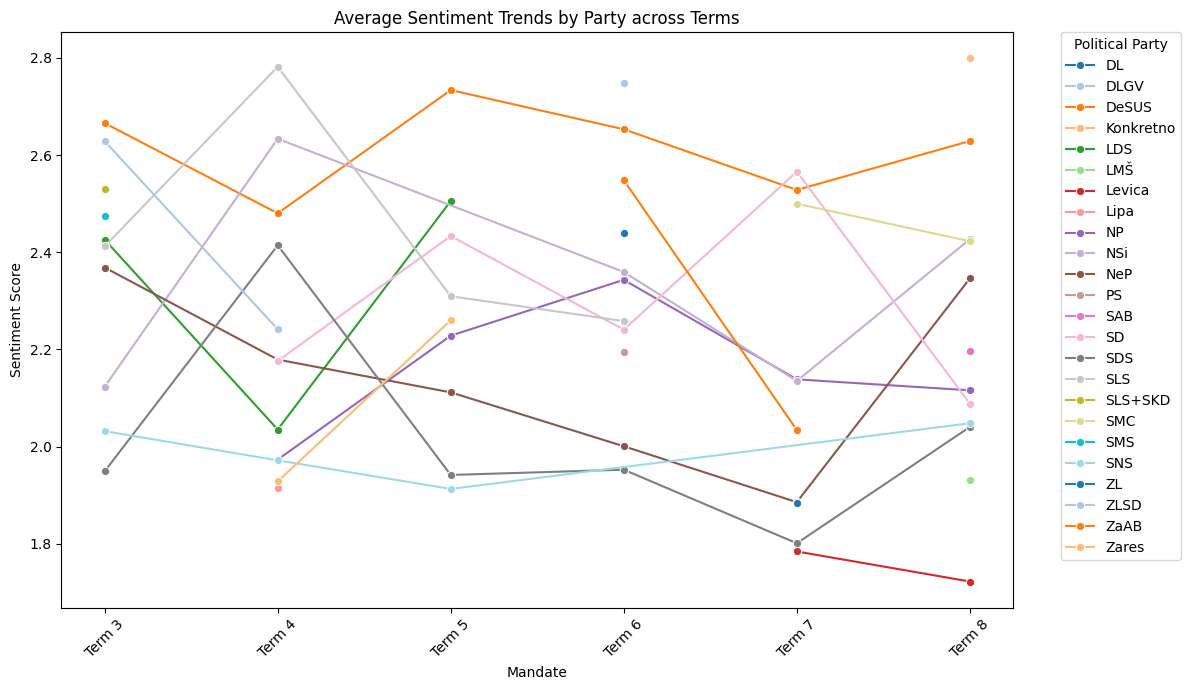

In [ ]:
plt.figure(figsize=(12, 7))
sns.lineplot(data=trends, x='Term', y='sent_annotations', hue='Speaker_party', marker='o', linewidth=1.5, palette='tab20')

plt.title('Average Sentiment Trends by Party across Terms')
plt.xlabel('Mandate')
plt.ylabel('Sentiment Score')
plt.legend(title='Political Party', loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
plt.xticks(rotation=45)
#plt.savefig('./Figures/Sentiment_Analysis/Sentences/Sentiment_Trends.png', dpi=300)

plt.tight_layout()



## Checking sentiment trends within each term

government = pd.DataFrame({
    'Government': ['Gov5', 'Gov6', 'Gov7', 'Gov8', 'Gov9', 'Gov10', 'Gov11', 'Gov12', 'Gov13', 'Gov14'],
    'Start_Date': ['2000-06-07', '2000-12-01', '2002-12-20', '2004-12-04', '2008-11-22', '2012-02-11', '2013-03-21', '2014-09-19', '2018-09-14', '2020-03-14'],
    'End_Date': ['2000-11-30', '2002-12-19', '2004-12-03', '2008-11-21', '2012-02-10', '2013-03-20', '2014-09-18', '2018-09-13', '2020-03-13', '2022-06-01']
})

government['Start_Date'] = pd.to_datetime(government['Start_Date'])
government['End_Date'] = pd.to_datetime(government['End_Date'])
government
terms['Date'] = pd.to_datetime(terms['Date'])

def map_government(date):
    for _, row in government.iterrows():
        if row['Start_Date'] <= date <= row['End_Date']:
            return row['Government']
    return None

terms['Government'] = terms['Date'].apply(map_government)

terms

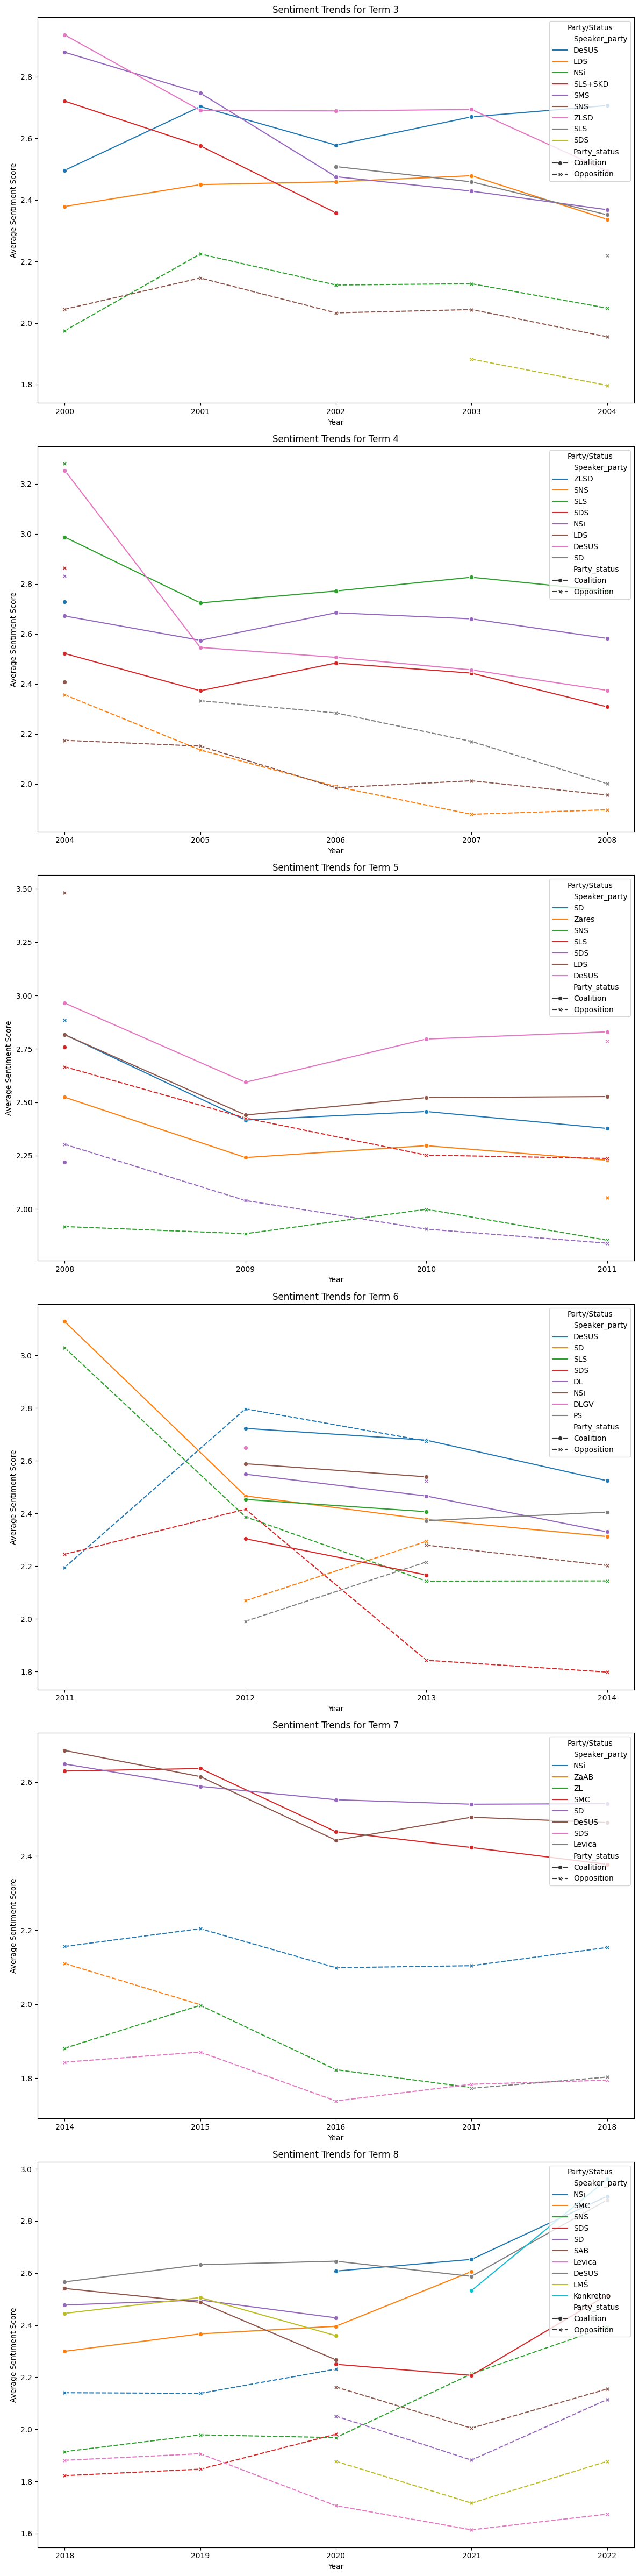

In [ ]:
term_sent = terms.groupby(['Term', 'Year', 'Speaker_party', 'Party_status']).agg({'sent_annotations':'mean'}).reset_index()
term_sent['Party_status'] = term_sent['Party_status'].astype('category')
term_sent = term_sent.sort_values(by='Year', ascending=True)

## Giving each individual political party a colour to be tracked throughout the subplots (not distinctive enough)
#unique_parties = term_sent['Speaker_party'].unique()
#party_palette = sns.color_palette("Set2", n_colors=len(unique_parties))
#party_color_mapping = {party: party_palette[i] for i, party in enumerate(unique_parties)}


n_terms = term_sent['Term'].unique()


fig, axes = plt.subplots(len(n_terms), 1, figsize=(12, 8 * len(n_terms)))

for i, term in enumerate(n_terms):
    ax = axes[i] if len(n_terms) > 1 else axes
    term_data = term_sent[term_sent['Term'] == term]

    sns.lineplot(data=term_data, x='Year', y='sent_annotations', hue='Speaker_party', style='Party_status' , ax=ax, markers=True)
    ax.set_title(f"Sentiment Trends for {term}")
    ax.set_xlabel('Year')
    ax.set_ylabel('Average Sentiment Score')
    ax.legend(title='Party/Status', loc='upper right')

plt.tight_layout()
#plt.savefig('./Figures/Sentiment_Analysis/Sentiment_for_Terms.png', dpi=300)

plt.show()



Interpretation of the trends witih individual mandate:

-Term 6: The overlap between the coalition and opposition values for certain political parties is due to the fact that there is a change in the government - Term 6 observes multiple government structures in its duration, namely: 
- 9. Vlada Republike Slovenije (21. 11. 2008 - 10. 2. 2012)
predsednik vlade Borut Pahor
- 10. Vlada Republike Slovenije (10. 2. 2012 - 20. 3. 2013)
predsednik vlade Janez Janša
- 11. Vlada Republike Slovenije (20. 3. 2013 - 18. 9. 2014)
predsednica vlade mag. Alenka Bratušek



In [ ]:
###Generating individual plots for a paper/chapter
for term in n_terms:
    term_data = term_sent[term_sent['Term'] == term]
    
    plt.figure(figsize=(12, 8))
    
    sns.lineplot(data=term_data, x='Year', y='sent_annotations', hue='Speaker_party',
                 style='Party_status', markers=True)
    
    plt.title(f"Sentiment Trends for {term}")
    plt.xlabel('Year')
    plt.ylabel('Average Sentiment Score')
    plt.legend(title='Party/Status', loc='upper right')
    
    plt.tight_layout()
    #plt.savefig(f'./Figures/Sentiment_Analysis/Terms/Sentiment_{term}.png', dpi=300)
    
    plt.close()

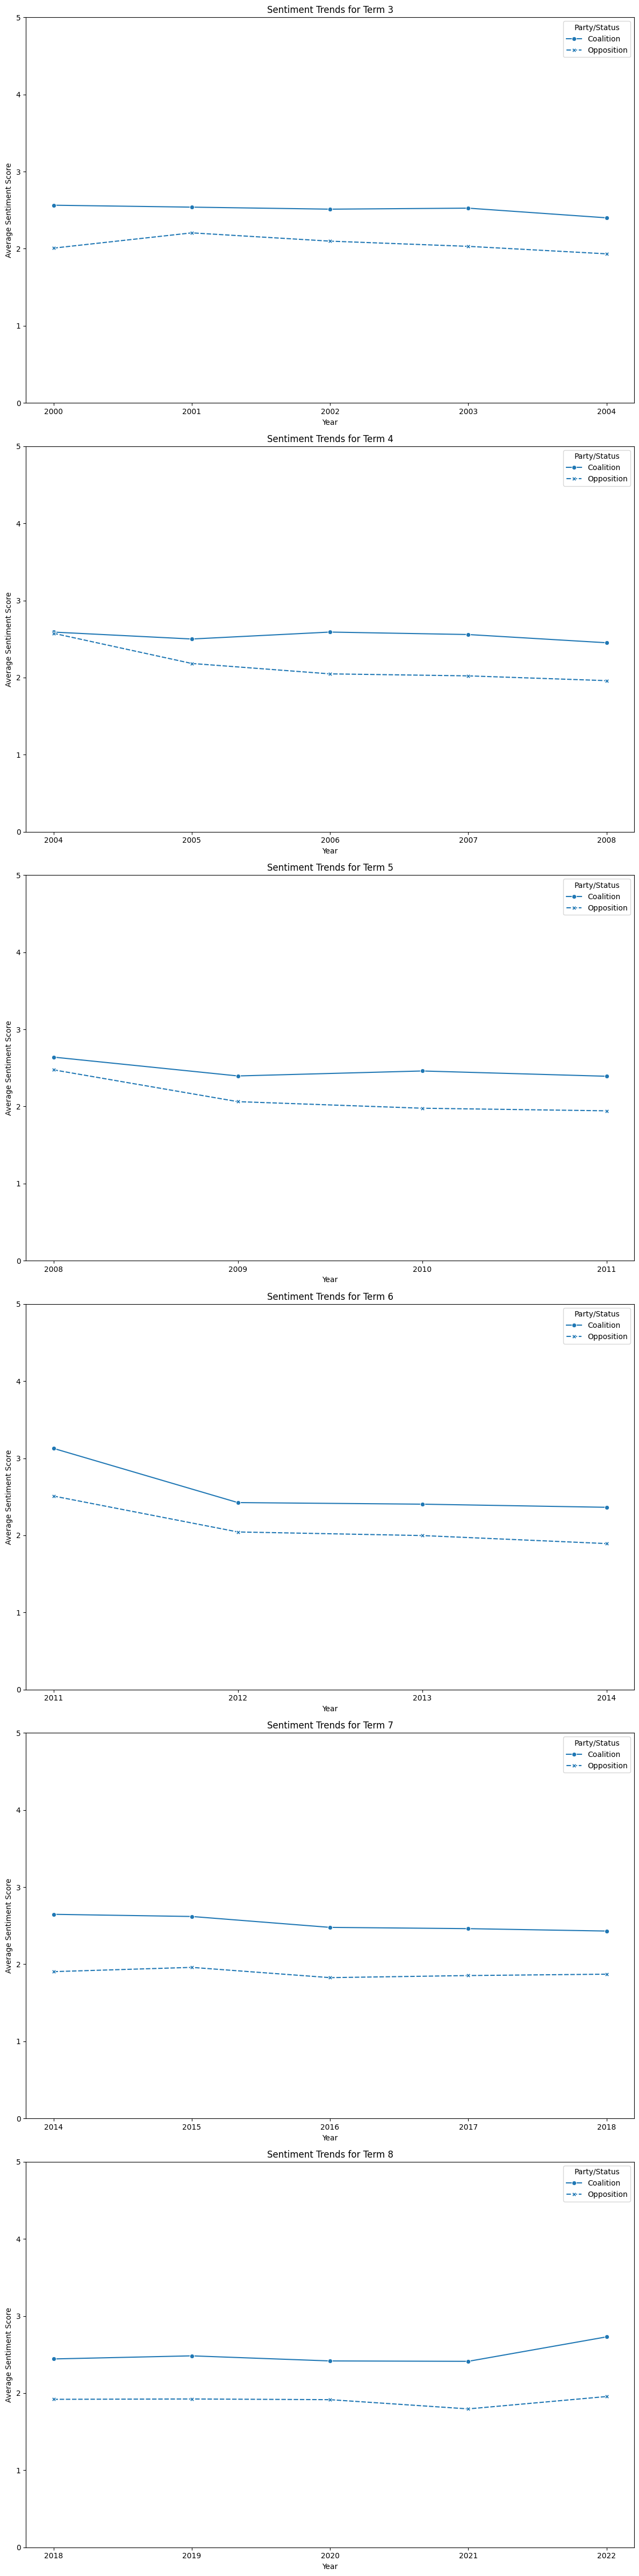

In [ ]:
status = terms.groupby(['Term', 'Year', 'Party_status']).agg({'sent_annotations':'mean'}).reset_index()
status['Party_status'] = status['Party_status'].astype('category')
status = status.sort_values(by='Year', ascending=True)

## Giving each individual political party a colour to be tracked throughout the subplots (not distinctive enough)
#unique_parties = term_sent['Speaker_party'].unique()
#party_palette = sns.color_palette("Set2", n_colors=len(unique_parties))
#party_color_mapping = {party: party_palette[i] for i, party in enumerate(unique_parties)}


n_terms = status['Term'].unique()


fig, axes = plt.subplots(len(n_terms), 1, figsize=(12, 8 * len(n_terms)))

for i, term in enumerate(n_terms):
    ax = axes[i] if len(n_terms) > 1 else axes
    term_data = status[status['Term'] == term]

    sns.lineplot(data=term_data, x='Year', y='sent_annotations', style='Party_status' , ax=ax, markers=True)
    ax.set_title(f"Sentiment Trends for {term}")
    ax.set_xlabel('Year')
    ax.set_ylabel('Average Sentiment Score')
    ax.set_ylim(0,5)
    ax.legend(title='Party/Status', loc='upper right')

plt.tight_layout()
#plt.savefig('./Figures/Sentiment_Analysis/Sentiment_for_Terms.png', dpi=300)

plt.show()

In [ ]:
#Producing individual plots for the Chapter/paper
for term in n_terms:
    term_data = status[status['Term'] == term]
    
    plt.figure(figsize=(12, 8))
    
    sns.lineplot(data=term_data, x='Year', y='sent_annotations', style='Party_status', markers=True)
    
    plt.title(f"Sentiment Trends for {term}")
    plt.xlabel('Year')
    plt.ylabel('Average Sentiment Score')
    plt.ylim(0,5)
    plt.legend(title='Party/Status', loc='upper right')
    
    plt.tight_layout()
    #plt.savefig(f'./Figures/Sentiment_Analysis/Sentences/Party_status_{term}.png', dpi=300)
    
    plt.close()

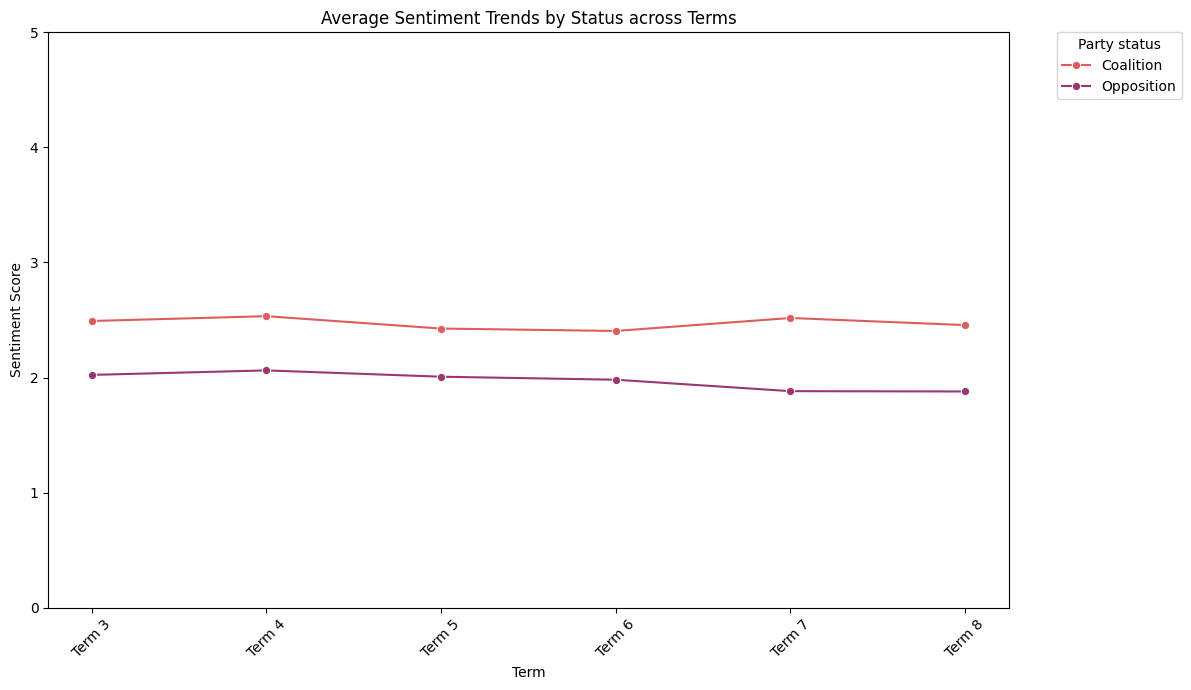

In [ ]:
terms_status = mandates.copy()
terms_status['sent_annotations'] = pd.to_numeric(terms_status['sent_annotations'])
trends_status = terms_status.groupby(['Party_status', 'Term']).agg({'sent_annotations':'mean'}).reset_index()
trends_status['Term'] = pd.Categorical(trends_status['Term'], ordered=True)

trends_status

plt.figure(figsize=(12, 7))

sns.lineplot(data=trends_status, x='Term', y='sent_annotations', hue='Party_status', marker='o', linewidth=1.5, palette='flare')

plt.title('Average Sentiment Trends by Status across Terms')
plt.xlabel('Term')
plt.ylabel('Sentiment Score')
plt.legend(title='Party status', loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
plt.xticks(rotation=45)
plt.ylim(0,5)
#plt.savefig('./Figures/Sentiment_Analysis/Sentences/PS_Sentiment_Trends.png', dpi=300)

plt.tight_layout()